# Introduction to MEEP for FDTD

##### Here we shall get acquainted with the use of Meep for FDTD simulations. For this demonstration, we are looking at the 2D periodic grating-like pattern with alternating air and dielectric layers, illuminated at normal incidence. Such structures are found on wing scales of *Morpho didius* butterfly and are well-known to give it the blue appearance (shown below)

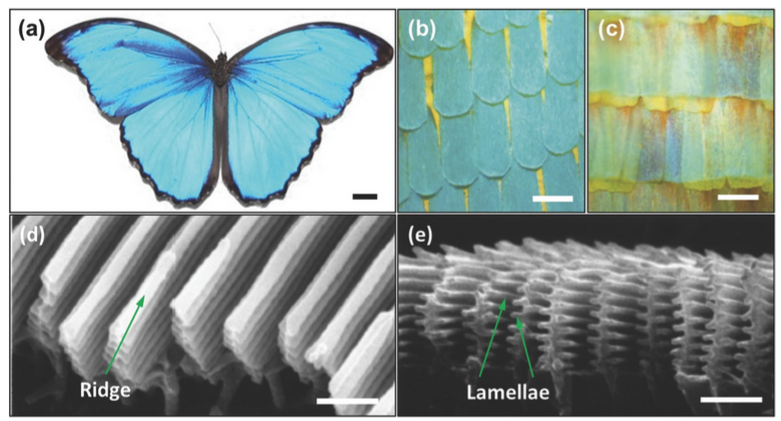

In [1]:
import meep as mp #imports Meep from your package
import numpy as np #Numerical python package for math operations on matrices and etc
import matplotlib.pyplot as plt #plotting package

##### Step 1: Define geometrical parameters for a single unit-cell

In [2]:
# Geometry parameters (units: microns)
period_x = 0.31 #periodicity of the structure
ridge_width = 0.08 #thickness of each ridge
ridge_spacing = 0.25 #width of each ridge
ridge_height = 1 #height of the overall structure
air_gap = 0.08 #alternating air gaps between each ridge

##### Step 2: Define resolution of the simulation

In [3]:
resolution = 100 #pixels per micron. Resolution in microns = 1/resolution

##### Step 3: Define simulation domain for the problem

In [4]:
dpml = 1.0 #thickness of the PML layer
sx = period_x #length of the simulation domain along x-direction. Same as the periodicity of the structure.
dair = 1.5 #thickness of the air region. Acts as space regions
sy = dpml + dair + ridge_height + dair + dpml  #length of the simulation domain along y-direction. 

cell_size = mp.Vector3(sx, sy, 0) #Defines the simulation boundaries to Meep

# Boundary conditions
boundary_layers = [mp.PML(dpml,direction=mp.Y)] #PML applies only along y-direction. Periodic boundaries along x.

##### Step 4: Define Materials. Here, we only have one material: Chitin with a refractive index of approximately $n=1.58$ at optical frequencies.

In [5]:
# Materials
chitin = mp.Medium(index=1.58)

##### Step 5: Define sources for the simulation. Here we choose a Gaussian pulse in time given by:
$\Large f(t) = Ae^{-\frac{(t-t_0)^2}{2\sigma_t^2}}\cos(\omega_0 t)\\$
with $\omega_0= \ $`f_cen` being the center of the frequency. $t_0$ and $\sigma_t$ are determined by the wavelength range of interest, which for us is 300 - 800 nm.

In [6]:
# Wavelength and source
f_start=1/0.8 #smallest frequency. The corresponding wavelength is 1/f (in microns)
f_end = 1/0.3 #largest frequency
f_cen=(f_start+f_end)/2 #central frequency in the gaussian of the frequency domain (fourier transform of our time-pulse)
f_width=f_end-f_start #width of the gaussian in the frequency domain 
nfreqs=200 #number of frequencies between f_start and f_end
# Angle of incidence
theta_deg = 0 #degrees
theta_rad = np.radians(theta_deg) #convert to radians
k = mp.Vector3(f_cen * np.sin(theta_rad), -f_cen * np.cos(theta_rad), 0) #the k-vector for the illumination. Since the simulation is 2D, kz=0

sources = [
    mp.Source(
        src=mp.GaussianSource(frequency=f_cen, fwidth=f_width),
        component=mp.Ez,  # TE polarization
        center=mp.Vector3(0,0.5*sy - dpml),
        size=mp.Vector3(sx, 0),
    )
]

##### Step 6: Construct the geometry. The structure is placed on top of a semi-infinite substrate of same refractive index.

In [ ]:
# Geometry construction: stacked ridges
geometry = []

num_ridges = int((ridge_height + air_gap) // (ridge_width + air_gap))
start_y = -0.5 * sy + dpml + dair + 0.5 * ridge_width
t_substrate = 0.5*sy - 0.5*ridge_height
for n in range(num_ridges):
    y_center = start_y + n * (ridge_width + air_gap)
    geometry.append(
        mp.Block(
            size=mp.Vector3(ridge_spacing, ridge_width, mp.inf),
            center=mp.Vector3(0, y_center),
            material=chitin
        )
    ) 
#constructs the horizontal ridges. mp.Block is a cuboidal geometrical object which can be placed anywhere inside the simulation domain. See meep references for other geometrical objects

geometry.append(
        mp.Block(
            size=mp.Vector3(ridge_width,ridge_height,0),
            material=chitin
        )) #constructs the vertical column in the center

geometry.append(
        mp.Block(
            size=mp.Vector3(sx,t_substrate,0),
            center=mp.Vector3(0,-0.5*t_substrate-0.5*ridge_height,0),
            material=chitin
        ) #constructs the substrate of the same material
)

##### Step 7: Construct the `Simulation` object. This tells MEEP everything it needs to know about initializing the simulation. Everything else can be added later. But first, since we want reflectance and transmittance of our structures, we need to know the incident flux without the structures ($P_{input}$). For this, we will perform an empty simulation and use the measured power to normalize our results later.

In [8]:
geometry0=[] # No geometry for the empty simulation

# Simulation object
sim = mp.Simulation(
    cell_size=cell_size,
    geometry=geometry0,
    sources=sources,
    boundary_layers=boundary_layers,
    resolution=resolution,
    k_point=k
)

##### Step 8: Define probes for measuring reflected and transmitted flux in the simulation domain. For a 3D simulation, typically it is a surface of size sx x sy. Since we have a 2D simulation, the probes are lines of size sx. 

In [9]:
trans_probe = mp.FluxRegion(center=mp.Vector3(0,-0.5*sy+dpml+ 0.7), #700 nm above the bottom-PML to avoid any spurious reflections from the boundary.
                        size=mp.Vector3(sx,0 ))

refl_probe = mp.FluxRegion(center=mp.Vector3(0,0.5*sy-dpml-0.7), #700 nm below the top-PML to avoid any spurious reflections from the boundary.
                        size=mp.Vector3(sx,0 ))
# transmitted flux
trans = sim.add_flux(f_cen, f_width, nfreqs, trans_probe) #add_flux records the flux in time and later fourier transforms to obtain the frequency response.
refl = sim.add_flux(f_cen, f_width, nfreqs, refl_probe)

##### Let's check our geometry so far for the empty simulation

<Axes: xlabel='X', ylabel='Y'>

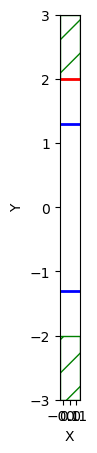

In [10]:
f = plt.figure(figsize=(25,5))
ax = f.add_subplot(1,1,1)
sim.plot2D(ax=ax)

##### The red marker at the top is the source of the simulation. Blue markers at top and bottom are the probes for measuring flux. The regions above and below are the PMLs.

##### Step 9: Start the simulation. Since we have a gaussian pulse in time, there will be no input flux after a certain point in time. If there are no resonances, the energy in the system will slowly decay and get eventually absorbed by the PMLs. The time-stepping is terminated when the measurement probe detects flux that is $10^{-3}$ times smaller than previous measurement.

In [11]:
#sim.run(until=100) #another way to run the simulation but doesn't necessarily guarantee convergence of results.
sim.run(
    
    until_after_sources=mp.stop_when_fields_decayed(
        20, mp.Ez, mp.Vector3(0, -0.5*sy - dpml+0.7 ), 1e-3
    ),
)

-----------
Initializing structure...
time for choose_chunkdivision = 0.000120878 s
Working in 2D dimensions.
Computational cell is 0.31 x 6 x 0 with resolution 100
time for set_epsilon = 0.0213749 s
-----------
Meep: using complex fields.
field decay(t = 20.005): 0.0006642036140537705 / 0.0006642036140537705 = 1.0
field decay(t = 40.005): 7.337694700139082e-28 / 0.0006642036140537705 = 1.1047357383913693e-24
run 0 finished at t = 40.005 (8001 timesteps)


##### Save the results for next run with the nanostructures.

In [12]:
init_flux = np.array(mp.get_fluxes(trans)) #incident flux at transmission probe as a function of frequencies. Takes the sign of the illumination direction.
init_flux_refl = sim.get_flux_data(refl) #Fourier-transformed fields recorded at the reflection probe as a function of number of pixels x number of frequencies x number of field components
freqs=np.array(mp.get_flux_freqs(trans)) #frequencies of the illumination. Wavelength = 1/np.array(freqs)

##### Step 10: Define the Simulation object but now with nanostructures. Everything else remains as before, only the geometry changes.

In [13]:
sim = mp.Simulation(
    cell_size=cell_size,
    geometry=geometry,
    #geometry=geometry0,
    sources=sources,
    boundary_layers=boundary_layers,
    resolution=resolution,
    k_point=k
)
trans_probe = mp.FluxRegion(center=mp.Vector3(0,-0.5*sy+dpml+ 0.7), #700 nm above the bottom-PML to avoid any spurious reflections from the boundary.
                        size=mp.Vector3(sx,0 ))

refl_probe = mp.FluxRegion(center=mp.Vector3(0,0.5*sy-dpml-0.7), #700 nm below the top-PML to avoid any spurious reflections from the boundary.
                        size=mp.Vector3(sx,0 ))

trans = sim.add_flux(f_cen, f_width, nfreqs, trans_probe) #same probes as before
refl = sim.add_flux(f_cen, f_width, nfreqs, refl_probe)

In [14]:
sim.load_minus_flux_data(refl,init_flux_refl) #The reflected fields from the empty simulation must be subtracted from the recorded fields now. Not needed for transmission probe.

-----------
Initializing structure...
time for choose_chunkdivision = 0.000287056 s
Working in 2D dimensions.
Computational cell is 0.31 x 6 x 0 with resolution 100
     block, center = (0,-0.46,0)
          size (0.25,0.08,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.4964,2.4964,2.4964)
     block, center = (0,-0.3,0)
          size (0.25,0.08,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.4964,2.4964,2.4964)
     block, center = (0,-0.14,0)
          size (0.25,0.08,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.4964,2.4964,2.4964)
     block, center = (0,0.02,0)
          size (0.25,0.08,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.4964,2.4964,2.4964)
     block, center = (0,0.18,0)
          size (0.25,0.08,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          diele

##### Visualize the geometry just for sanity check

     block, center = (0,-0.46,0)
          size (0.25,0.08,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.4964,2.4964,2.4964)
     block, center = (0,-0.3,0)
          size (0.25,0.08,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.4964,2.4964,2.4964)
     block, center = (0,-0.14,0)
          size (0.25,0.08,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.4964,2.4964,2.4964)
     block, center = (0,0.02,0)
          size (0.25,0.08,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.4964,2.4964,2.4964)
     block, center = (0,0.18,0)
          size (0.25,0.08,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.4964,2.4964,2.4964)
     block, center = (0,0.34,0)
          size (0.25,0.08,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
  

<Axes: xlabel='X', ylabel='Y'>

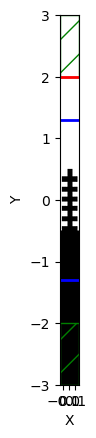

In [15]:
sim.plot2D()

##### Step 11: Run the simulation again but now with the geometry. Stop the time-stepping once the fields decay at the transmission probe by a factor of $10^{-3}$ from the previous measurement time.

     block, center = (0,-0.46,0)
          size (0.25,0.08,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.4964,2.4964,2.4964)
     block, center = (0,-0.3,0)
          size (0.25,0.08,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.4964,2.4964,2.4964)
     block, center = (0,-0.14,0)
          size (0.25,0.08,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.4964,2.4964,2.4964)
     block, center = (0,0.02,0)
          size (0.25,0.08,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.4964,2.4964,2.4964)
     block, center = (0,0.18,0)
          size (0.25,0.08,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.4964,2.4964,2.4964)
     block, center = (0,0.34,0)
          size (0.25,0.08,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
  

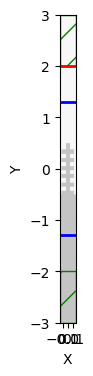

In [16]:
f = plt.figure(figsize=(3,4)) # figure window to record the fields in time. Not neccessary. 
animate = mp.Animate2D(f=f, fields=mp.Ez, realtime=False, normalize=True) #Meep object for animating fields

sim.run(
    mp.at_every(0.2, animate),
    until_after_sources=mp.stop_when_fields_decayed(
        20, mp.Ez, mp.Vector3(0, -0.5*sy - dpml+0.7 ), 1e-3
    ),
)

In [ ]:
from IPython.display import Video

filename = "butterfly_fdtd.mp4"
animate.to_mp4(4, filename)
Video(filename) #generates the video and saves it under the given filename

Generating MP4...


##### Save the recorded fields as before

In [18]:
transmitted_flux = np.array(mp.get_fluxes(trans)) #fluxes at the transmission probe as a function of frequencies
#flux_refl = sim.get_flux_data(refl) # not needed here
reflected_flux = np.array(mp.get_fluxes(refl)) #fluxes at the reflection probe as a function of frequencies

##### Step 12: Visualize the results. The transmission $T(\lambda)$ and reflection $R(\lambda)$ are plotted as a function of wavelength (1/freqs). Remember to normalize the results by $P_{input}$.

Text(0, 0.5, 'Reflectance and Transmittance')

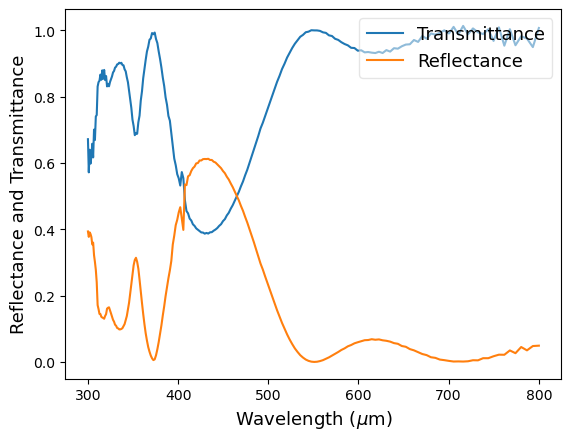

In [21]:
wavelength_array = 1e3 * 1/freqs
plt.plot(wavelength_array,transmitted_flux/init_flux,label='Transmittance') #normalize by init_flux
plt.plot(wavelength_array,-reflected_flux/init_flux,label='Reflectance') #normalize by init_flux. Negative sign because of the back-reflection
plt.legend(fontsize=13,loc='upper right',framealpha=0.5)
plt.xlabel('Wavelength ($\mu$m)',fontsize=13)
plt.ylabel('Reflectance and Transmittance',fontsize=13)


##### Notice the big spike in $R(\lambda)$ in the 400-500nm spectral region. This already indicates a blue color, but we will map $R(\lambda)$ to R,G,B values using tristimulus values X,Y,Z given by: $X = \int_{\lambda}R(\lambda)\bar{x}(\lambda)d\lambda$,   $Y = \int_{\lambda}R(\lambda)\bar{y}(\lambda)d\lambda$  and  $Z = \int_{\lambda}R(\lambda)\bar{z}(\lambda)d\lambda$

##### Where $\bar{x}(\lambda),\bar{y}(\lambda),\bar{z}(\lambda)$ are the Color Matching Functions describing color perception of a human-eye. These are then mapped to R,G,B values. To avoid over-complicating the problem here, I skip it's implementation and directly show the results.

In [ ]:
import color_system as csys # CAUTION not a part of this package. Would fail to run if tried

cs = csys.cs_hdtv

rgb = cs.spectrum_to_rgb( np.c_[wavelength_array,-reflected_flux/init_flux] )

plt.figure(figsize=(2, 2))
plt.imshow([[rgb]], aspect='auto')

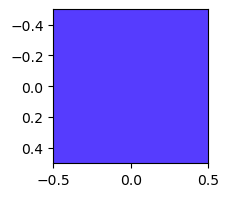

#### The color that comes out is blue! Even a simple 2D model of our structures is able to capture the characteristic blue color. Needless to say, precise results for visual appearance should be obtained by finer considerations like mean height, width of the ridges, full 3D simulation, etc.